<a href="https://colab.research.google.com/github/hyui02/ESAA_assignment/blob/main/%08YB_WEEK03_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Simple Exploration Notebook-Instacart

The dataset for this competition is a relation set of files describing customers' orders overtime.

##Objective

The goal of the competition is **to predict which products will be in a user's next order**. The dataset is anonymized and contains a sample of over 3 million grocery orders from more than 200,000 Instacart users.

For each user, 4 and 100 of their orders are given, with the sequence of products purchased in each order

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
color= sns.color_palette()

%matplotlib inline

pd.options.mode.chained_assignment = None #default='warn'

- %matplotlib inline: 과거 주피터에선 기본적으로 맷플롯립이 어떤 백엔드로 그림 그릴지 몰라서 해당 코드가 필요했음, 하지만 ipykernel이 개선되면서, 노트북 환경에서 실행 중이라는 걸 자동으로 감지해 인라인 백엔드를 알아서 켜주도록 바뀜 => 불필요한 코드

- pd.options.mode.chained_assignment = None:판다스에서 데이터프레임 일부를 슬라이싱해서 값을 바꿀 때 뜨는 SettingWithCopyWarning을 꺼주는 설정


In [2]:
order_products_train_df= pd.read_csv('/content/order_products__train.csv')
order_products_prior_df= pd.read_csv('/content/order_products__prior.csv')
orders_df=pd.read_csv('/content/orders.csv')
products_df= pd.read_csv('/content/products.csv')
aisles_df= pd.read_csv('/content/aisles.csv')
departments_df= pd.read_csv('/content/departments.csv')

In [3]:
orders_df.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


In [4]:
order_products_prior_df.head()

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


In [5]:
order_products_train_df.head()

,order_id,product_id,add_to_cart_order,reordered
0,1,49302,1,1
1,1,11109,2,1
2,1,10246,3,0
3,1,49683,4,0
4,1,43633,5,1


- orders.csv: 특정 주문 id에 대한 정보들
  - eval_set: 행이 세가지 데이터 셋(prior, train, test) 중 어디에 속하는지 알려줌
- order_products_prior: 해당 고객의 마지막 주문 이전의 모든 정보 주문 정보
- order_products.csv: 특정 주문에서 구매된 상품들에
대한 좀 더 상세한 정보, 재주문 여부


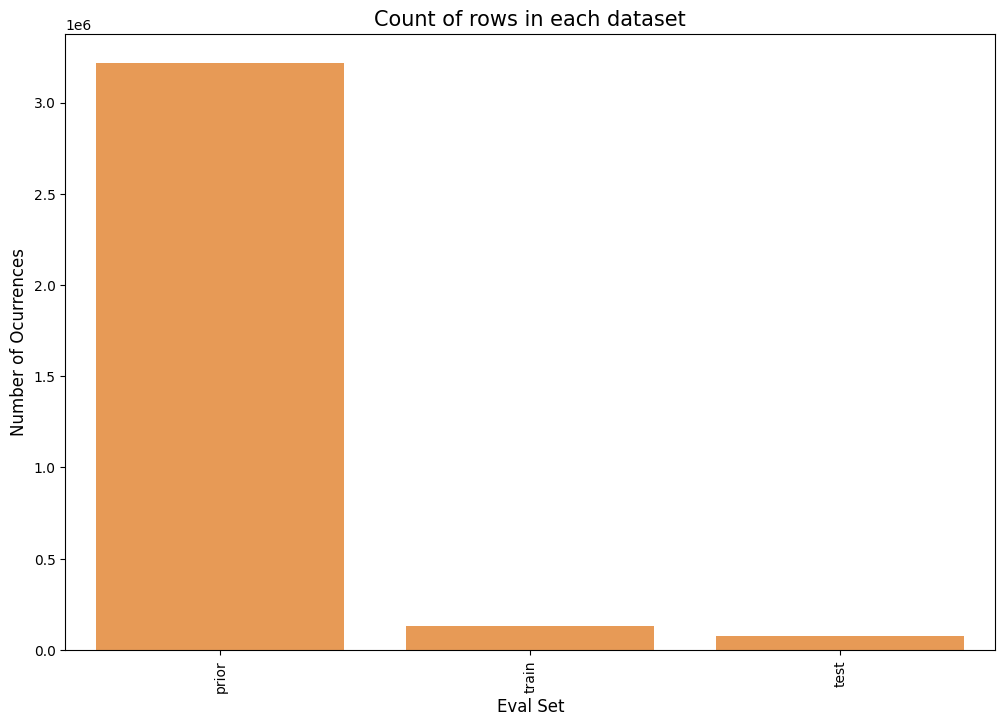

In [6]:
cnt_srs = orders_df.eval_set.value_counts()

plt.figure(figsize=(12,8))
sns.barplot(x=cnt_srs.index, y=cnt_srs.values, alpha=0.8, color=color[1])
plt.ylabel('Number of Ocurrences', fontsize=12 )
plt.xlabel('Eval Set', fontsize=12)
plt.title('Count of rows in each dataset', fontsize=15)
plt.xticks(rotation='vertical')
plt.show()

##고객 충성도 확인
유저별 최대 구매횟수

In [7]:
def get_unique_count(x):
  return len(np.unique(x))

cnt_srs = orders_df.groupby("eval_set")["user_id"].aggregate(get_unique_count)
cnt_srs

,user_id
eval_set,
prior,206209
test,75000
train,131209


- get_unique_count= 함수 이름
- x: get_u~ 가 받는 매개변수, 즉 입력값
- len(np.unique(x)): x를 가지고 계산한 결과값


/tmp/ipykernel_78399/3614049113.py:2: FutureWarning: The provided callable <function max at 0x7983a23534c0> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  "order_number"].aggregate(np.max).reset_index()


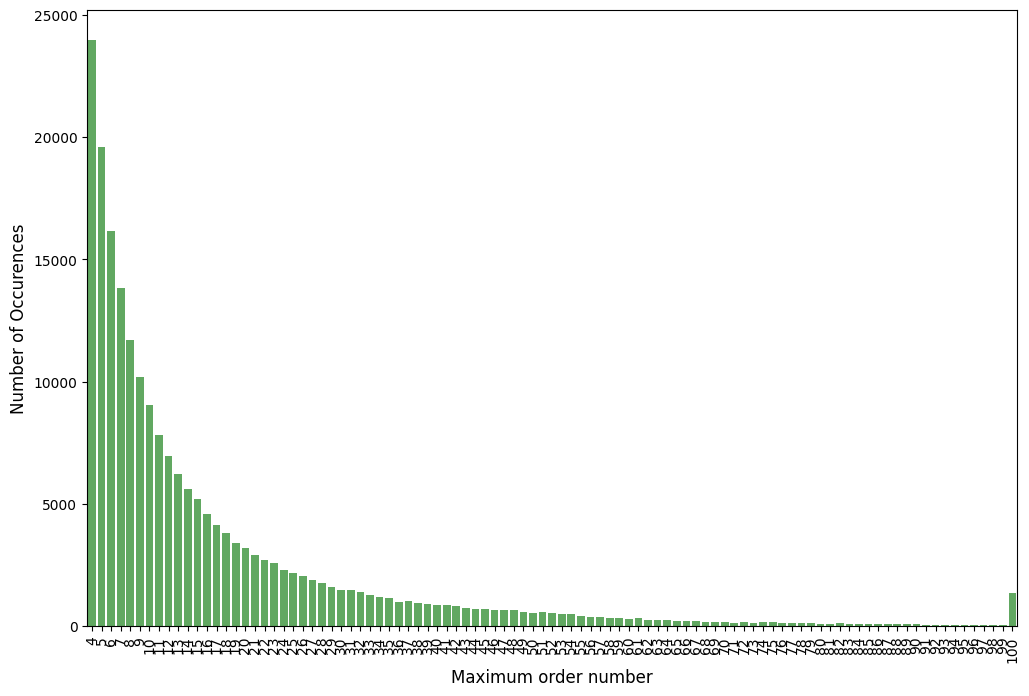

In [8]:
cnt_srs= orders_df.groupby("user_id")[
    "order_number"].aggregate(np.max).reset_index()
cnt_srs=cnt_srs.order_number.value_counts()

plt.figure(figsize=(12,8))
sns.barplot(x=cnt_srs.index, y=cnt_srs.values, alpha=0.8, color=color[2])
plt.ylabel('Number of Occurences',fontsize=12)
plt.xlabel('Maximum order number', fontsize=12)
plt.xticks(rotation='vertical')
plt.show()

4개 미만인 주문은 없고, 최대치는 100개 제한

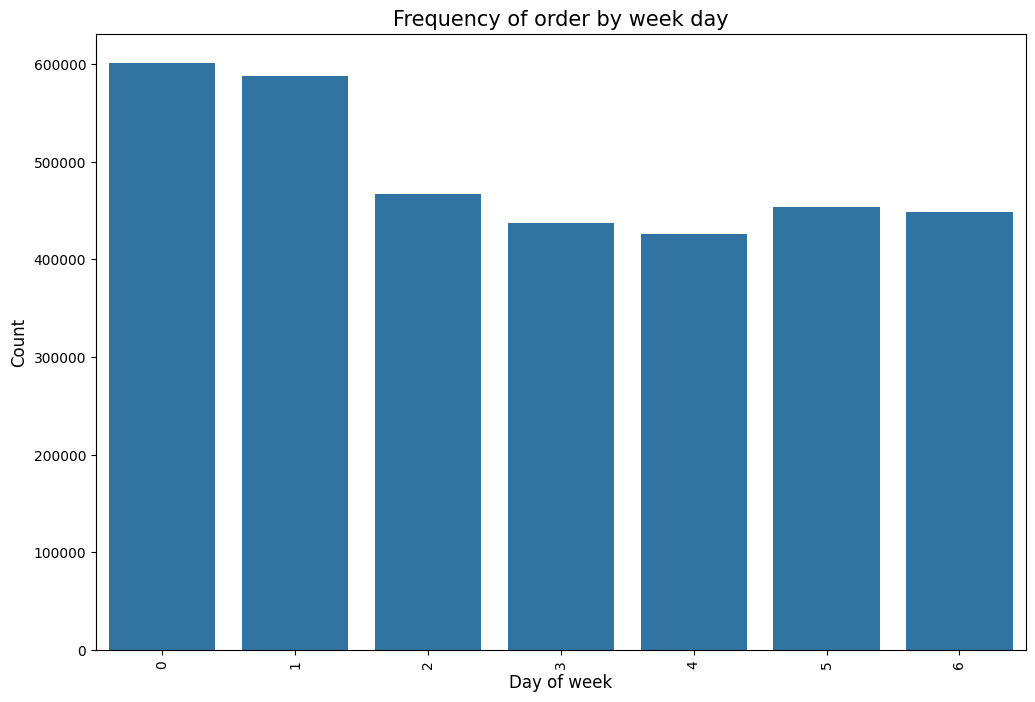

In [9]:
plt.figure(figsize=(12,8))
sns.countplot(x='order_dow', data=orders_df, color=color[0])
plt.ylabel('Count',fontsize=12)
plt.xlabel('Day of week',fontsize=12)
plt.xticks(rotation='vertical')
plt.title("Frequency of order by week day", fontsize=15)
plt.show()

결과 분석: 0과 1이 각각 토,일 (주문량 夕)
수요일 주문량 적음

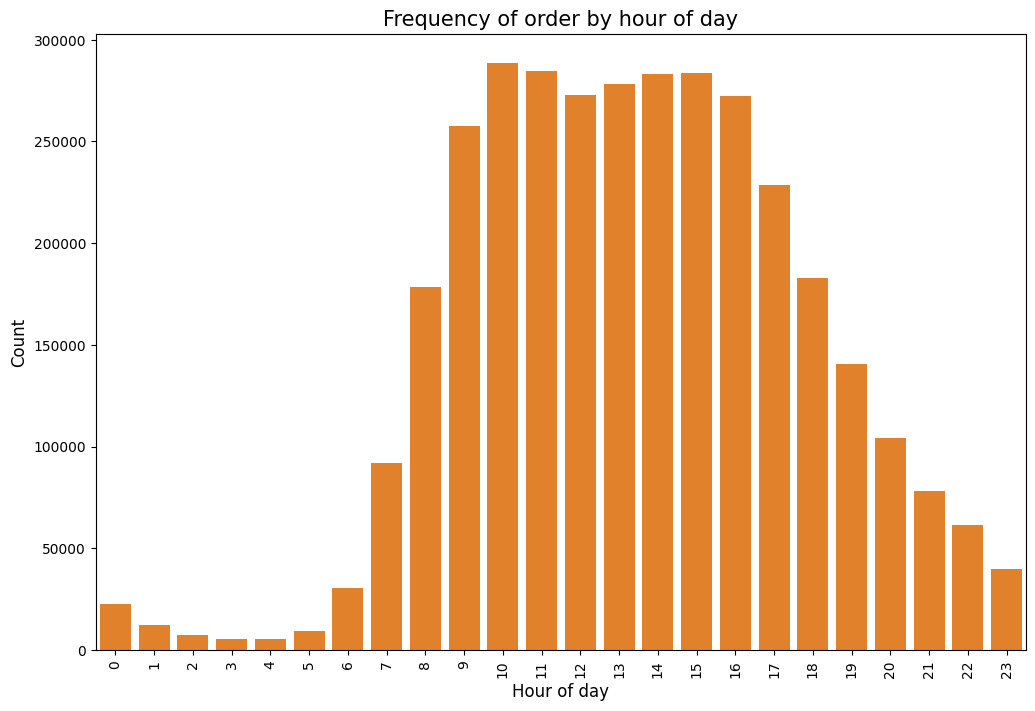

In [10]:
plt.figure(figsize=(12,8))
sns.countplot(x="order_hour_of_day",data=orders_df, color=color[1])
plt.ylabel('Count',fontsize=12)
plt.xlabel('Hour of day',fontsize=12)
plt.xticks(rotation='vertical')
plt.title("Frequency of order by hour of day", fontsize=15)
plt.show()

결과 분석: 낮 시간대에 주문이 많음
=> 요일과 시간대 조합

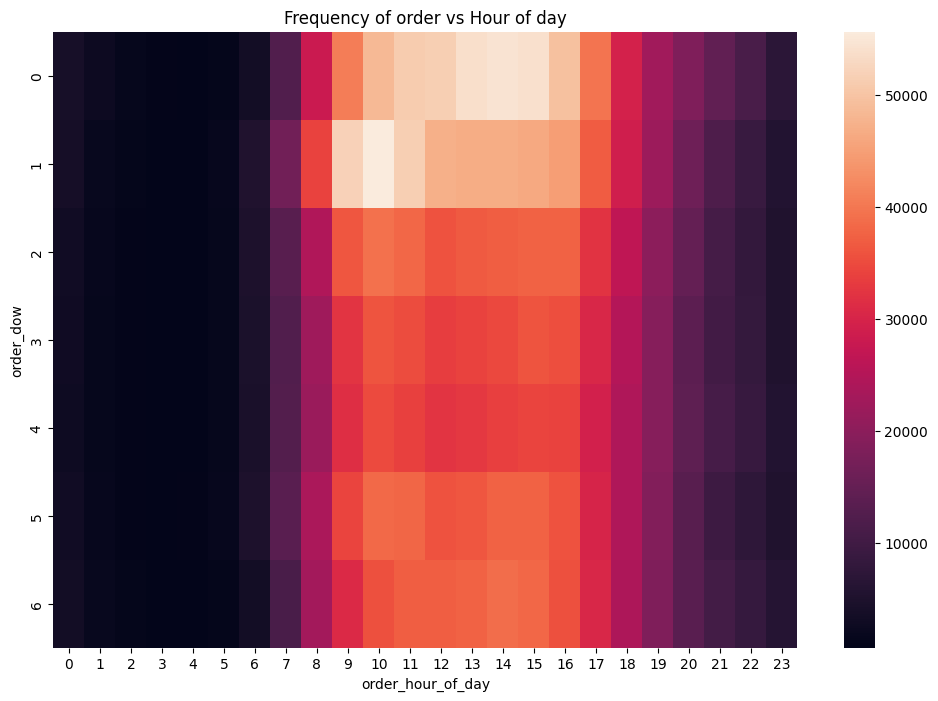

In [11]:
grouped_df= orders_df.groupby(["order_dow","order_hour_of_day"])["order_number"].aggregate("count").reset_index()
grouped_df = grouped_df.pivot(index='order_dow',columns='order_hour_of_day', values='order_number')

plt.figure(figsize=(12,8))
sns.heatmap(grouped_df)
plt.title("Frequency of order vs Hour of day")
plt.show()

- 결과 분석: 토요일 저녁과 일요일 아침이 주문이 가장 많이몰리는 시간대

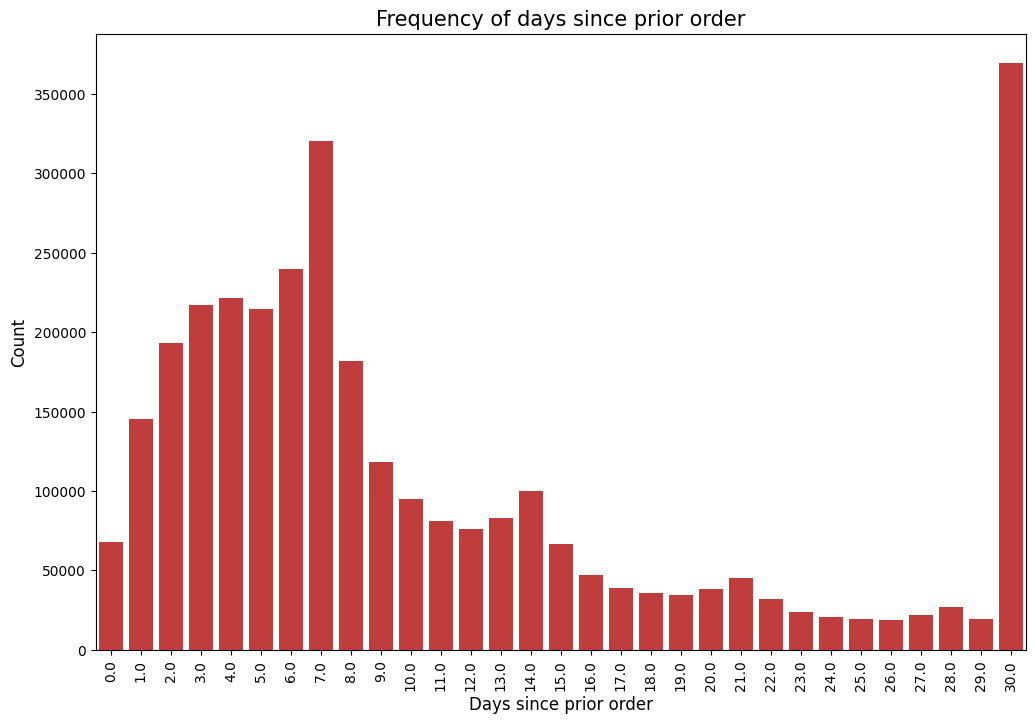

In [12]:
plt.figure(figsize=(12,8))
sns.countplot(x='days_since_prior_order', data=orders_df, color=color[3])
plt.ylabel('Count',fontsize=12)
plt.xlabel('Days since prior order',fontsize=12)
plt.xticks(rotation='vertical')
plt.title("Frequency of days since prior order", fontsize=15)
plt.show()

-고객들은 일주일에 한번 또는 한달에 한번 주문하는 경향이 있음, 또한 14,21,28일 지점에도(주 단위)에도 주변보다는 약간 높음

In [13]:
#percentage of re-orders in prior set #
order_products_prior_df.reordered.sum()/order_products_prior_df.shape[0]

np.float64(0.5896974667922161)

In [14]:
#percentage of re-orders in train set #
order_products_train_df.reordered.sum()/ order_products_train_df.shape[0]

np.float64(0.5985944127509629)

결과분석: 59퍼가 재구문함

In [15]:
grouped_df=order_products_prior_df.groupby("order_id")[
    "reordered"].aggregate("sum").reset_index()
grouped_df["reordered"].loc[grouped_df["reordered"]>1] = 1
grouped_df.reordered.value_counts()/grouped_df.shape[0]

/tmp/ipykernel_78399/3564134878.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  grouped_df["reordered"].loc[grouped_df["reordered"]>1] = 1


,count
reordered,
1,0.879151
0,0.120849


In [16]:
grouped_df= order_products_train_df.groupby("order_id")["reordered"].aggregate("sum").reset_index()
grouped_df["reordered"].loc[grouped_df["reordered"]>1] = 1
grouped_df.reordered.value_counts()/ grouped_df.shape[0]

/tmp/ipykernel_78399/390920800.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  grouped_df["reordered"].loc[grouped_df["reordered"]>1] = 1


,count
reordered,
1,0.93444
0,0.06556


결과 분석: prior 약 12%가 재주문 상품 x, train셋에선 6.5%

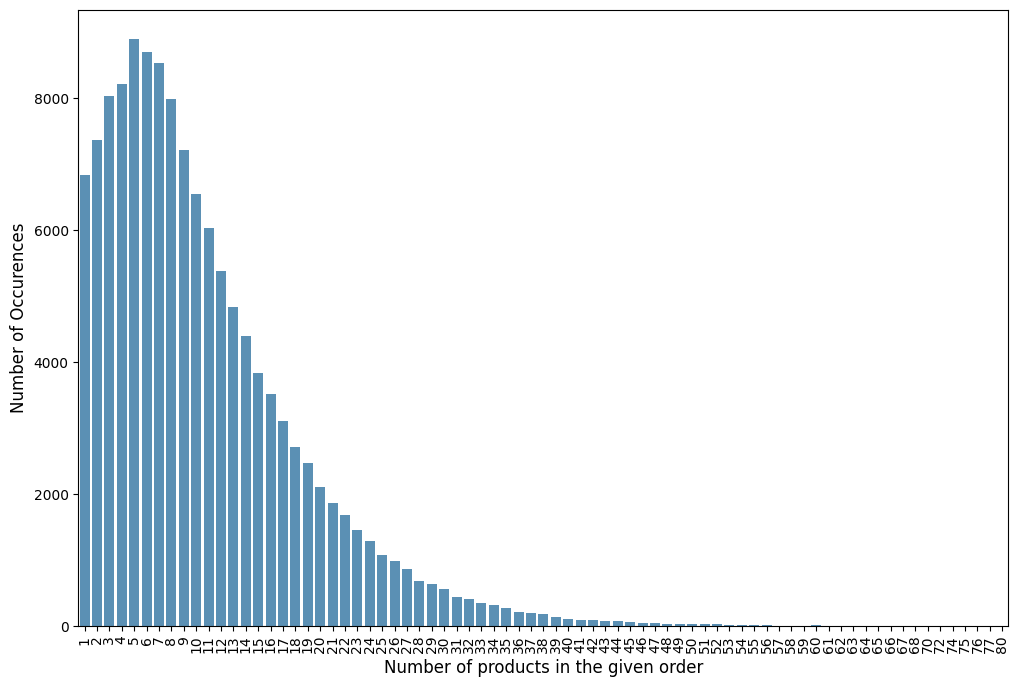

In [17]:
grouped_df= order_products_train_df.groupby("order_id")[
    "add_to_cart_order"].aggregate("max").reset_index()
cnt_srs= grouped_df.add_to_cart_order.value_counts()

plt.figure(figsize=(12,8))
sns.barplot(x=cnt_srs.index, y=cnt_srs.values, alpha=0.8)
plt.ylabel('Number of Occurences',fontsize=12)
plt.xlabel('Number of products in the given order', fontsize=12)
plt.xticks(rotation='vertical')
plt.show()

In [18]:
products_df.head()

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [19]:
aisles_df.head()

,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


In [20]:
departments_df.head()

,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


In [21]:
order_products_prior_df = pd.merge(order_products_prior_df, products_df, on='product_id', how='left')
order_products_prior_df = pd.merge(order_products_prior_df, aisles_df, on='aisle_id', how='left')
order_products_prior_df = pd.merge(order_products_prior_df, departments_df, on='department_id', how='left')
order_products_prior_df.head()

,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,department
0,2,33120,1,1,Organic Egg Whites,86,16,eggs,dairy eggs
1,2,28985,2,1,Michigan Organic Kale,83,4,fresh vegetables,produce
2,2,9327,3,0,Garlic Powder,104,13,spices seasonings,pantry
3,2,45918,4,1,Coconut Butter,19,13,oils vinegars,pantry
4,2,30035,5,0,Natural Sweetener,17,13,baking ingredients,pantry


- how='left': 판다스의 merge() 함수에서 두 데이터프레임을 합칠 때 왼쪽 데이터프레임 기준으로 합치는 것을 의미

In [22]:
cnt_srs= order_products_prior_df['product_name'].value_counts().reset_index().head(20)
cnt_srs.case_when=['product_name','frequency_count']
cnt_srs

/tmp/ipykernel_78399/3998056382.py:2: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  cnt_srs.case_when=['product_name','frequency_count']


,product_name,count
0,Banana,472565
1,Bag of Organic Bananas,379450
2,Organic Strawberries,264683
3,Organic Baby Spinach,241921
4,Organic Hass Avocado,213584
5,Organic Avocado,176815
6,Large Lemon,152657
7,Strawberries,142951
8,Limes,140627
9,Organic Whole Milk,137905


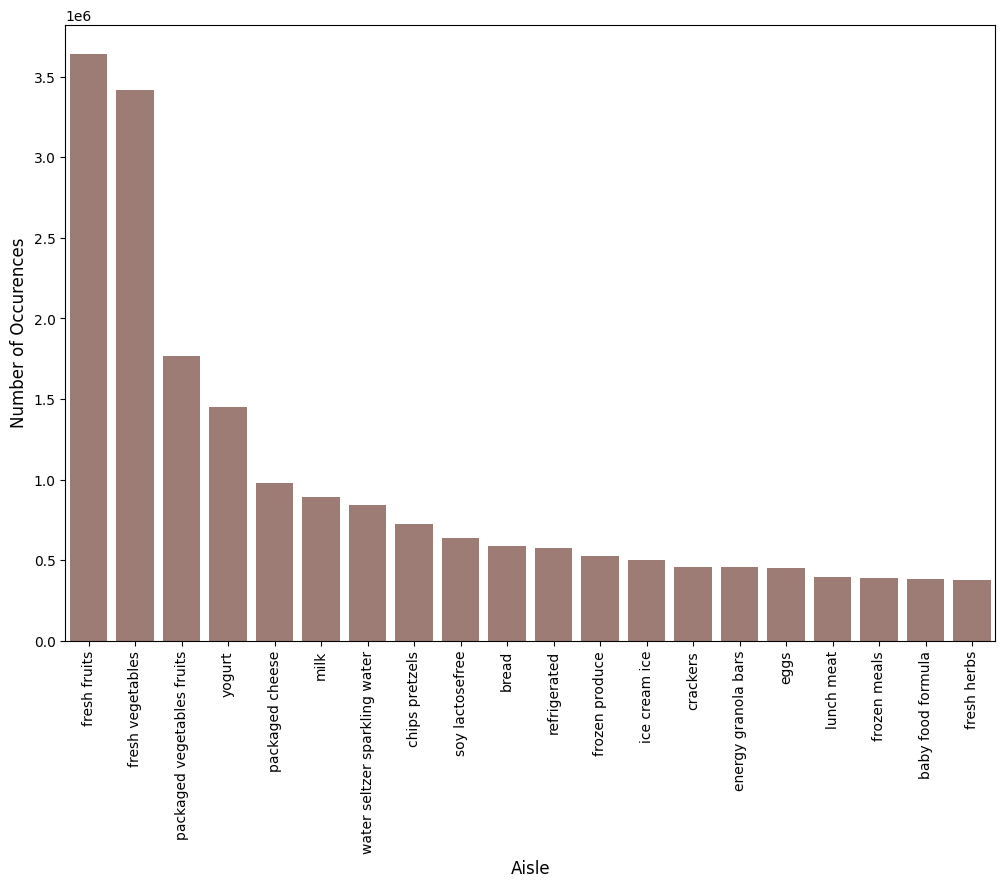

In [23]:
cnt_srs= order_products_prior_df['aisle'].value_counts().head(20)
plt.figure(figsize=(12,8))
sns.barplot(x=cnt_srs.index, y=cnt_srs.values, alpha=0.8, color=color[5])
plt.ylabel('Number of Occurences', fontsize=12)
plt.xlabel('Aisle', fontsize=12)
plt.xticks(rotation='vertical')
plt.show()

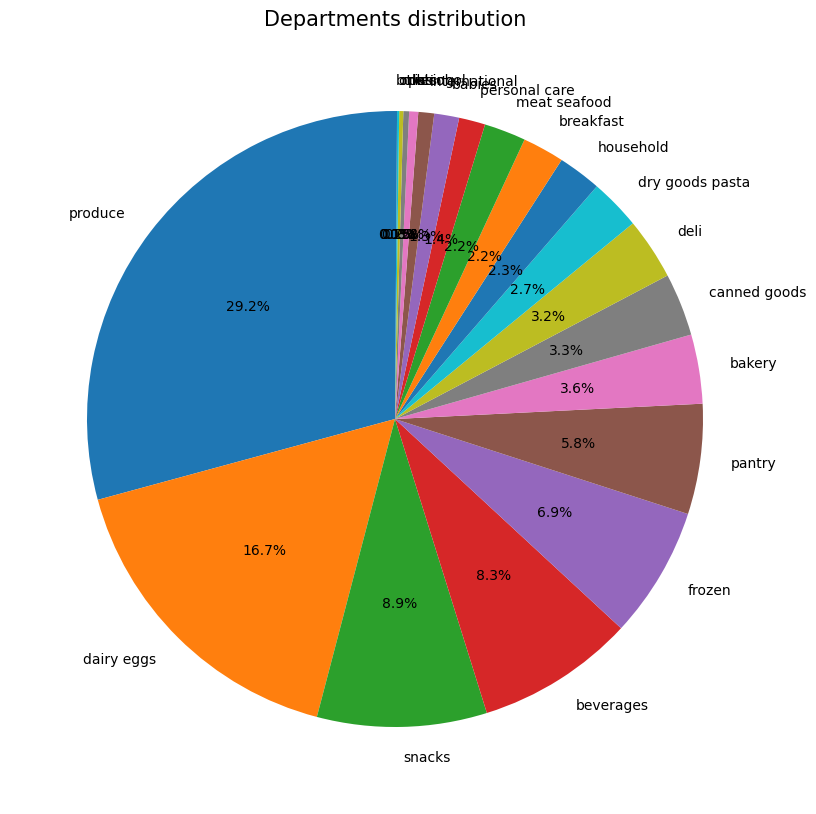

In [24]:
plt.figure(figsize=(10,10))
temp_series= order_products_prior_df['department'].value_counts()
labels=(np.array(temp_series.index))
sizes=(np.array((temp_series/temp_series.sum())*100))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90) #원그래프
plt.title("Departments distribution",fontsize=15)
plt.show()

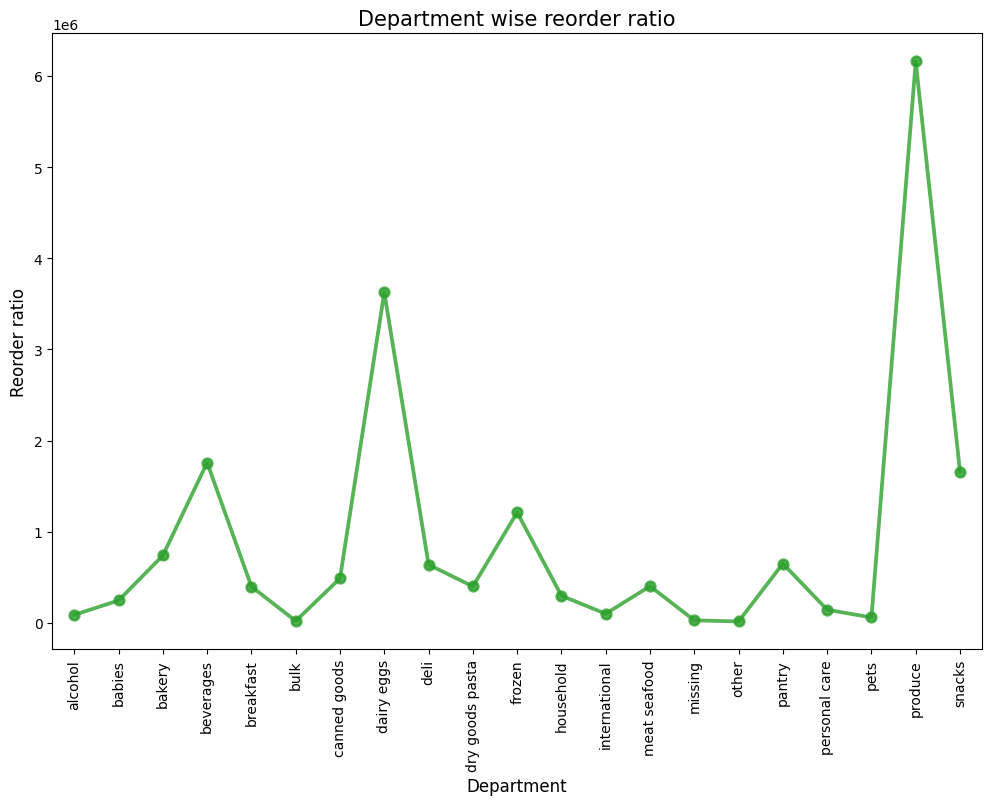

In [25]:
grouped_df=order_products_prior_df.groupby("department")["reordered"].aggregate("sum").reset_index()

plt.figure(figsize=(12,8))
sns.pointplot(x=grouped_df['department'].values, y=grouped_df['reordered'].values,
              alpha=0.8, color=color[2])
plt.ylabel('Reorder ratio',fontsize=12)
plt.xlabel('Department',fontsize=12)
plt.title("Department wise reorder ratio", fontsize=15)
plt.xticks(rotation='vertical')
plt.show()

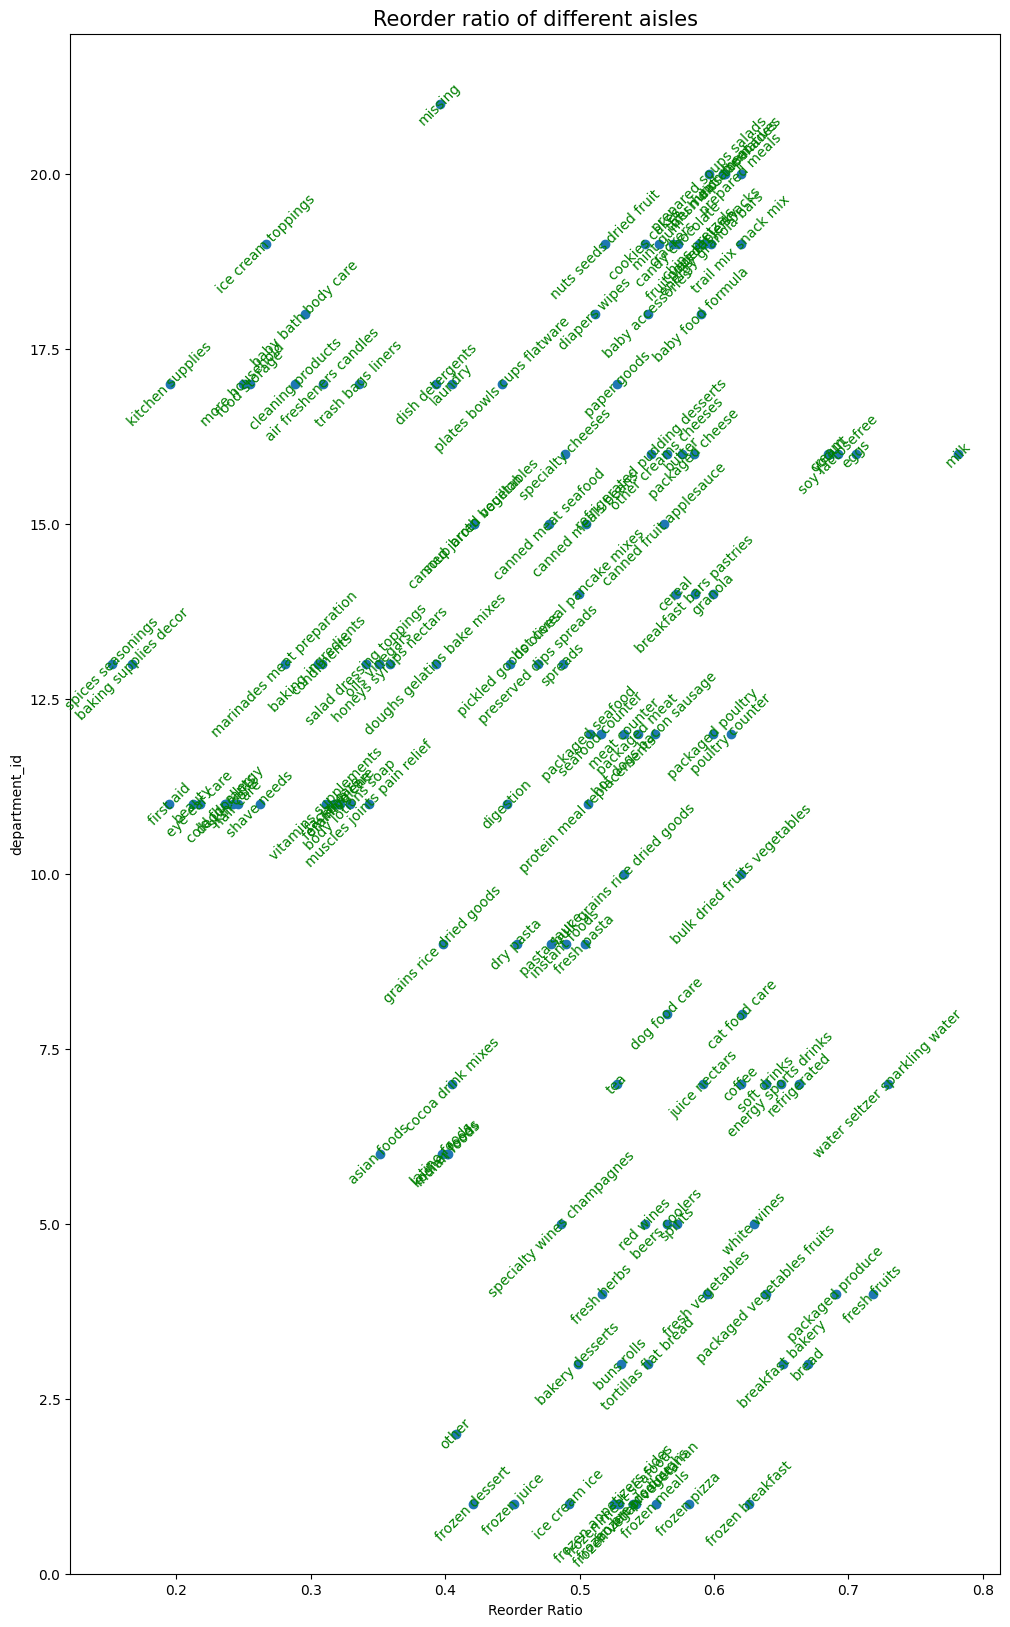

In [26]:
grouped_df= order_products_prior_df.groupby(["department_id", "aisle"])[
    "reordered"].aggregate("mean").reset_index()

fig, ax=plt.subplots(figsize=(12,20))
ax.scatter(grouped_df.reordered.values, grouped_df.department_id.values)
for i,txt in enumerate(grouped_df.aisle.values):
  ax.annotate(txt, (grouped_df.reordered.values[i], grouped_df.department_id.values[i]),
              rotation=45, ha='center',va='center', color='green')
plt.xlabel('Reorder Ratio')
plt.ylabel('department_id')
plt.title("Reorder ratio of different aisles", fontsize=15)
plt.show()

/tmp/ipykernel_78399/2302597602.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  order_products_prior_df["add_to_cart_order_mod"].loc[order_products_prior_df["add_to_cart_order_mod"]> 70] = 70


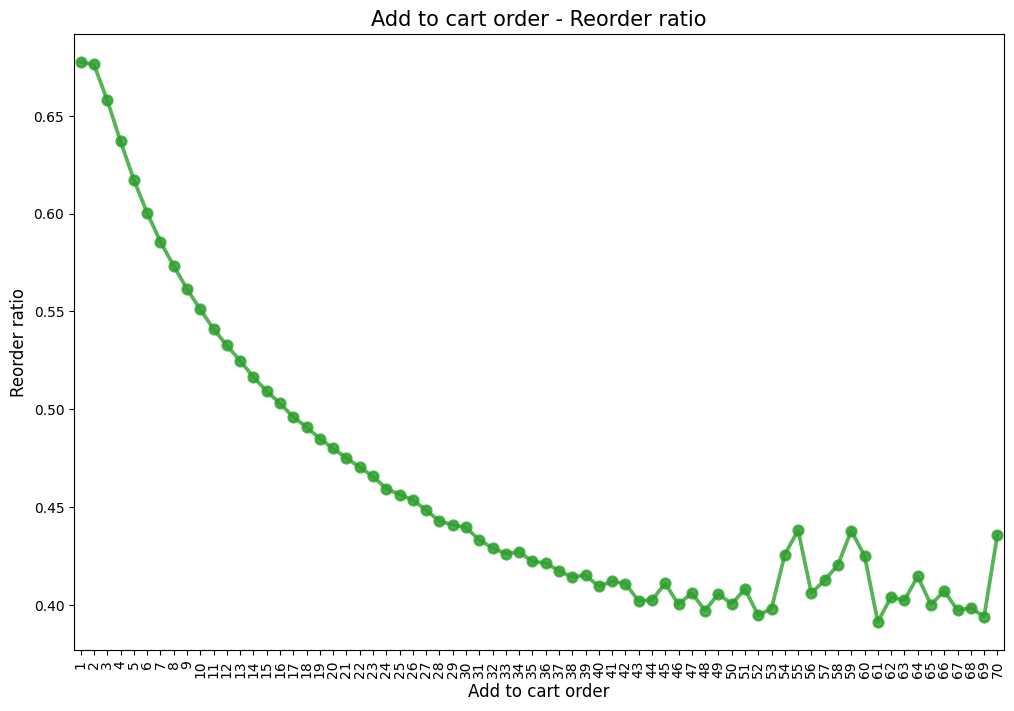

In [27]:
order_products_prior_df["add_to_cart_order_mod"]=order_products_prior_df["add_to_cart_order"].copy()
order_products_prior_df["add_to_cart_order_mod"].loc[order_products_prior_df["add_to_cart_order_mod"]> 70] = 70
grouped_df=order_products_prior_df.groupby(["add_to_cart_order_mod"])[
    "reordered"].aggregate("mean").reset_index()

plt.figure(figsize=(12,8))
sns.pointplot(x=grouped_df['add_to_cart_order_mod'].values, y=grouped_df['reordered'].values, alpha=0.8, color=color[2])
plt.ylabel('Reorder ratio',fontsize=12)
plt.xlabel('Add to cart order',fontsize=12)
plt.title("Add to cart order - Reorder ratio", fontsize=15)
plt.xticks(rotation='vertical')
plt.show()

- 장바구니에 처음에 담긴 상품일수록, 나중에 담긴 상품보다 재주문될 확률이 더 높은 것으로 보임

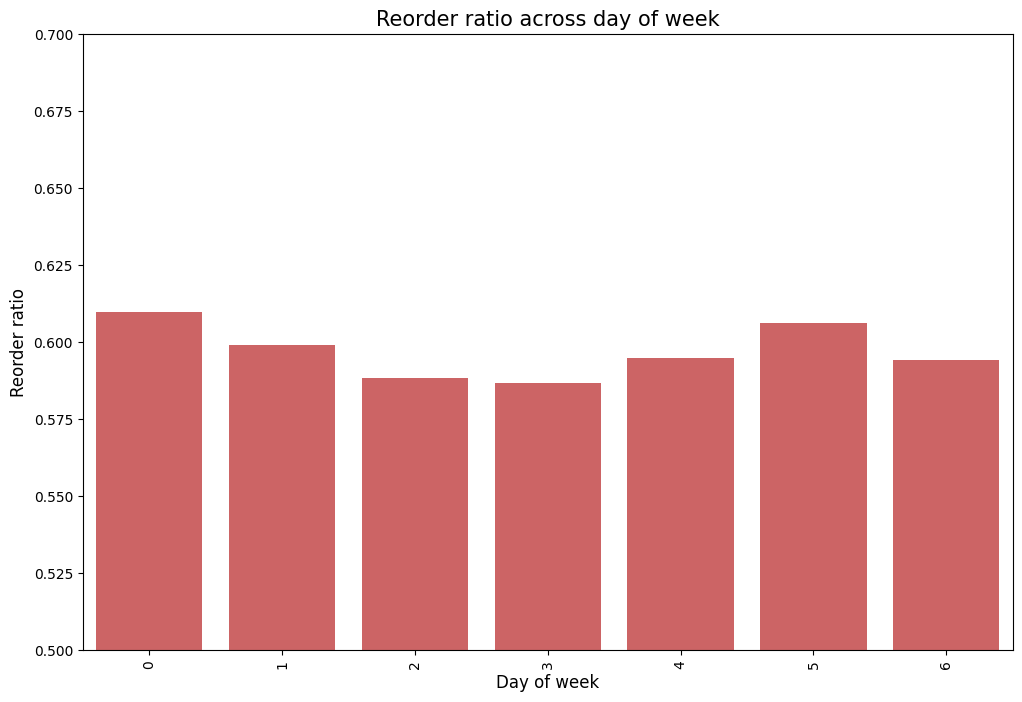

In [28]:
order_products_train_df=pd.merge(order_products_train_df, orders_df, on='order_id',
                                 how='left')
grouped_df= order_products_train_df.groupby(["order_dow"])["reordered"].aggregate("mean").reset_index()

plt.figure(figsize=(12,8))
sns.barplot(x=grouped_df['order_dow'].values, y=grouped_df['reordered'].values, alpha=0.8, color=color[3])
plt.ylabel('Reorder ratio',fontsize=12)
plt.xlabel('Day of week',fontsize=12)
plt.title("Reorder ratio across day of week", fontsize=15)
plt.xticks(rotation='vertical')
plt.ylim(0.5,0.7)
plt.show()

- plt.ylim(): 그래프의 Y축 표시 범위를 설정하거나 현재 범위를 확인할 때 사용

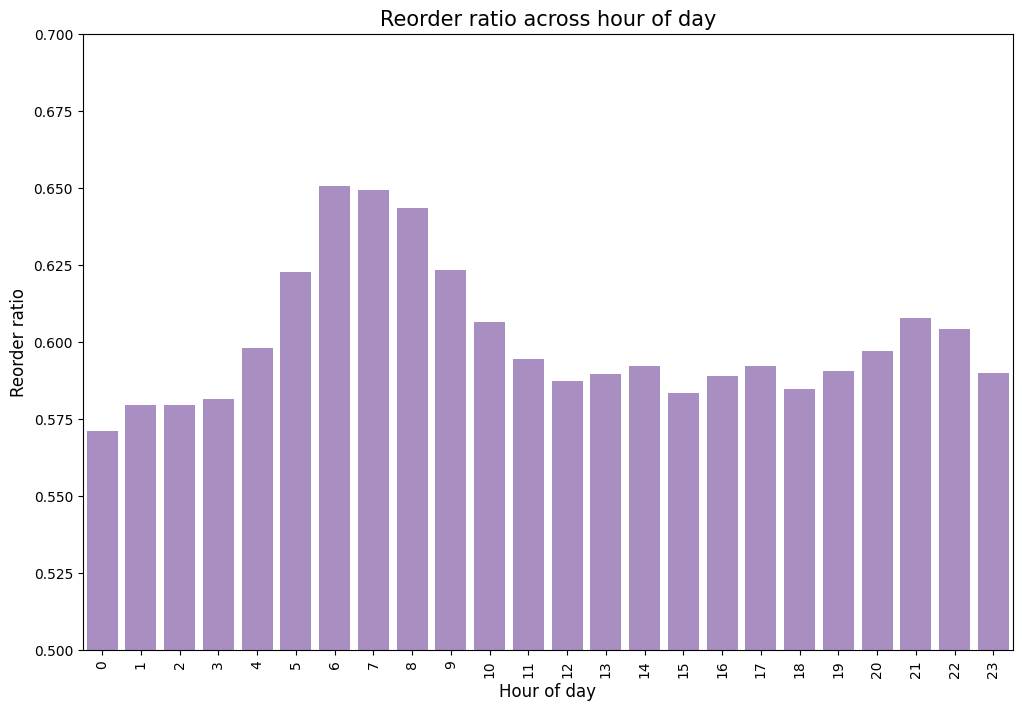

In [29]:
grouped_df= order_products_train_df.groupby(["order_hour_of_day"])["reordered"].aggregate("mean").reset_index()

plt.figure(figsize=(12,8))
sns.barplot(x=grouped_df['order_hour_of_day'].values, y=grouped_df['reordered'].values, alpha=0.8, color=color[4])
plt.ylabel('Reorder ratio',fontsize=12)
plt.xlabel('Hour of day',fontsize=12)
plt.title("Reorder ratio across hour of day", fontsize=15)
plt.xticks(rotation='vertical')
plt.ylim(0.5,0.7)
plt.show()

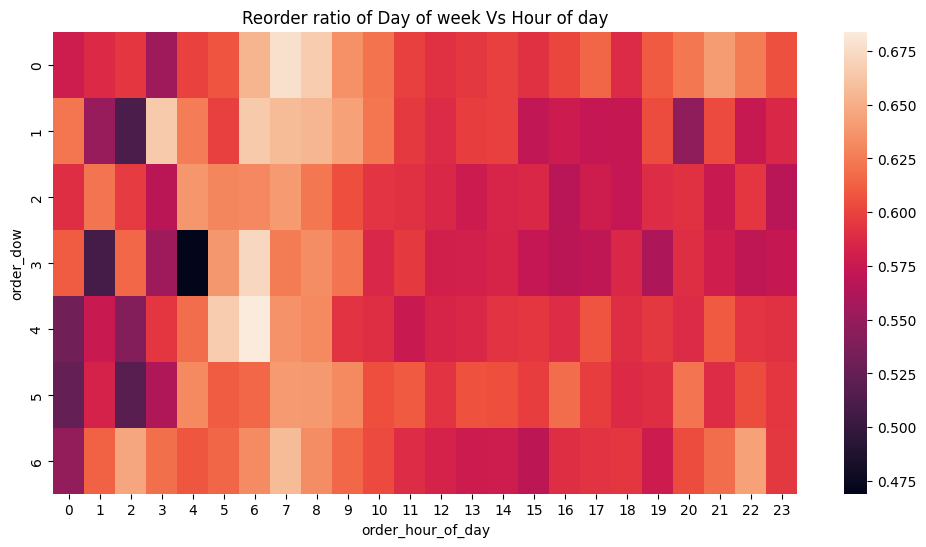

In [30]:
grouped_df = order_products_train_df.groupby(["order_dow", "order_hour_of_day"])["reordered"].aggregate("mean").reset_index()
grouped_df = grouped_df.pivot(index='order_dow',columns='order_hour_of_day', values='reordered')

plt.figure(figsize=(12,6))
sns.heatmap(grouped_df)
plt.title("Reorder ratio of Day of week Vs Hour of day")
plt.show()

#새로운 전처리
1. 사용자별 재구매율
2. 상품별 재구매 순위

###1. 사용자별 재구매율

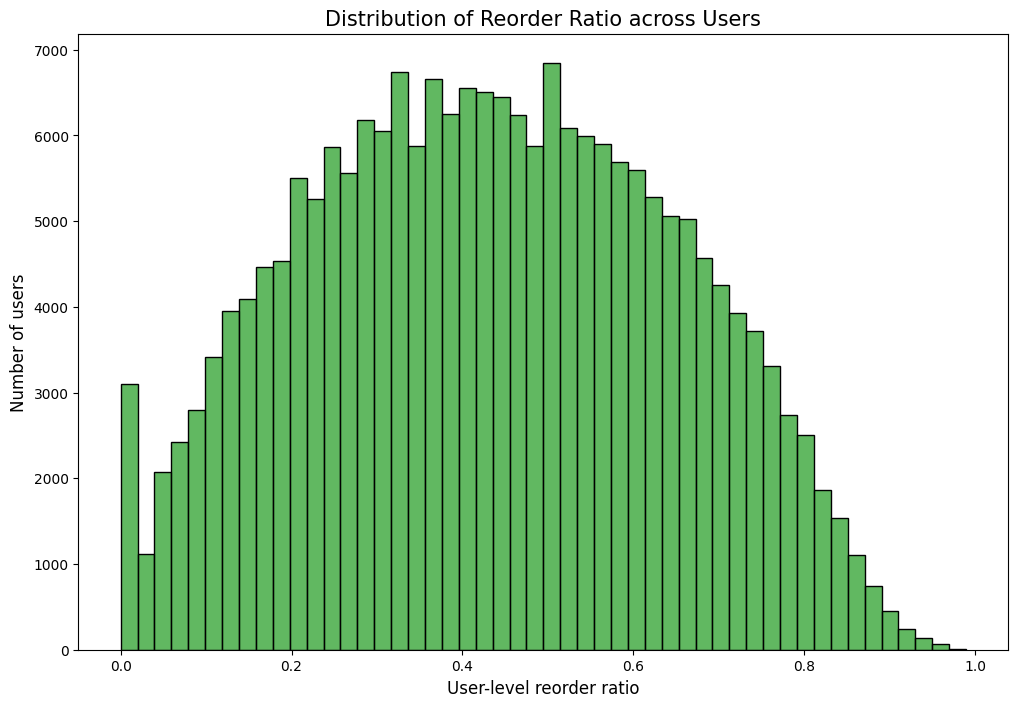

In [31]:
user_reorder = order_products_prior_df.merge(orders_df[['order_id', 'user_id']], on='order_id', how='left') \
    .groupby('user_id')['reordered'].mean().reset_index(name='user_reorder_ratio')

plt.figure(figsize=(12,8))
sns.histplot(user_reorder['user_reorder_ratio'], bins=50, color=color[2])
plt.ylabel('Number of users', fontsize=12)
plt.xlabel('User-level reorder ratio', fontsize=12)
plt.title('Distribution of Reorder Ratio across Users', fontsize=15)
plt.show()

In [32]:
print(user_reorder['user_reorder_ratio'].describe())

count    206209.000000
mean          0.432249
std           0.212144
min           0.000000
25%           0.267857
50%           0.428571
75%           0.595745
max           0.989529
Name: user_reorder_ratio, dtype: float64


- 재구매율이 0%인 유저: 3000명 이상
- 재구매율이 100%인 유저: 0명
- Q. 유저별 평균 재구매율은 약 43.2%이지만, 전체 상품 기준으로 재구매율은 58.97%?
  - A. 전자는 유저 하나하나를 동일하게 고려했고 후자는 헤비유저의 상품이 훨씬 많이 반영된 가중평균이기 때문으로 보임
    -> 이 가설을 검증하기 위해, 헤비유저의 기준 설립 및 그룹화. 그룹별 재구매 비율 분석

In [33]:
user_order_count = orders_df.groupby('user_id')['order_number'].max().reset_index(name='order_count')
user_stats = user_reorder.merge(user_order_count, on='user_id', how='left')

print("order count vs user reorder ratio corr:",user_stats['order_count'].corr(user_stats['user_reorder_ratio']))

order count vs user reorder ratio corr: 0.6368909763348806


유저의 총 주문 횟수와 그 유저의 재구매 비율 사이에 강한 양의 상관관계

In [34]:
q1 = user_stats['order_count'].quantile(0.25)
q3 = user_stats['order_count'].quantile(0.75)
light_users = user_stats[user_stats['order_count'] <= q1]
heavy_users = user_stats[user_stats['order_count'] >= q3]
print(f"라이트 유저 기준(주문 {q1:.0f}회 이하): 평균 재구매율 {
    light_users['user_reorder_ratio'].mean():.4f}, 인원 {len(light_users)}명")
print(f"헤비 유저 기준(주문 {q3:.0f}회 이상): 평균 재구매율 {
    heavy_users['user_reorder_ratio'].mean():.4f}, 인원 {len(heavy_users)}명")

라이트 유저 기준(주문 6회 이하): 평균 재구매율 0.2455, 인원 59741명
헤비 유저 기준(주문 20회 이상): 평균 재구매율 0.6436, 인원 53931명


헤비 유저쪽으로 전체 평균이 쏠림을 뒷받침해줌-> 전체 상품 기준일 때 재구매율이 왜 높은 . 지이해가 됨

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44172 (\N{HANGUL SYLLABLE GE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47566 (\N{HANGUL SYLLABLE MANH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

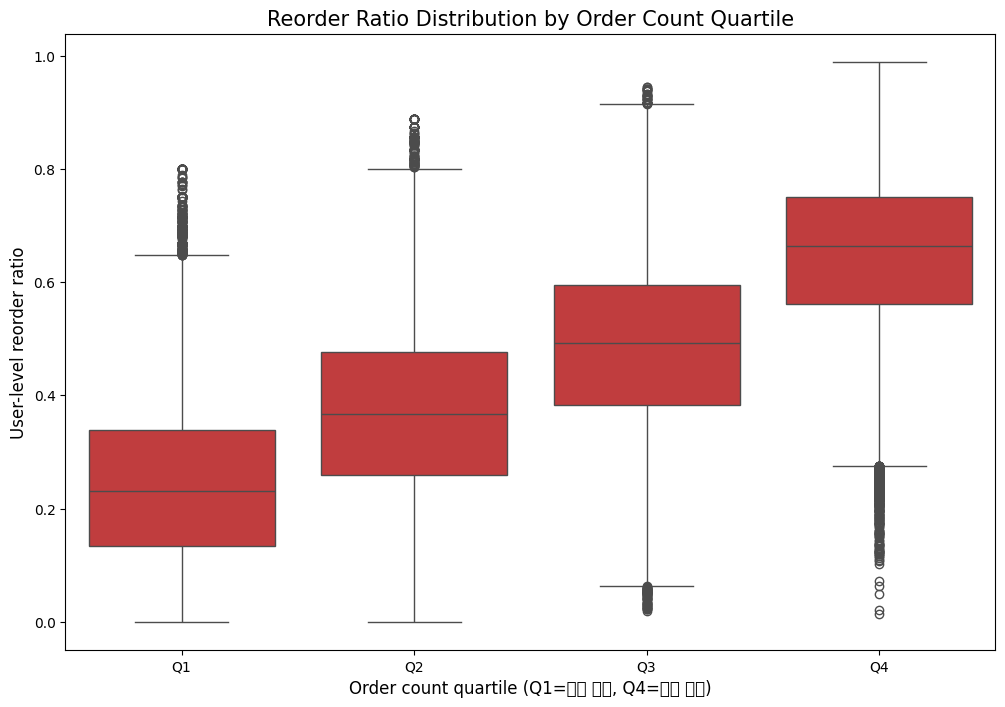

In [35]:
user_stats['order_count_quartile'] = pd.qcut(user_stats['order_count'], 4, labels=['Q1', 'Q2', 'Q3', 'Q4'], duplicates='drop')

plt.figure(figsize=(12,8))
sns.boxplot(x=user_stats['order_count_quartile'], y=user_stats['user_reorder_ratio'], color=color[3])
plt.ylabel('User-level reorder ratio', fontsize=12)
plt.xlabel('Order count quartile (Q1=적게 주문, Q4=많이 주문)', fontsize=12)
plt.title('Reorder Ratio Distribution by Order Count Quartile', fontsize=15)
plt.show()

- 검증 결과: 주문 횟수와 재구매율의 상관계수는 0.64로 강한 양의 상관관계였고, Q1부터 Q4까지 겹침 없이 계단식으로 증가함.
##결론
 가설이 입증됨, 상품 단위 평균이 유저 단위 평균보다 높았던 이유는 주문을 많이 한 헤비유저의 데이터가 상품 단위 통계에 과대 반영

##2. 상품별 재구매 순위
- 단순히 상품이 뭐가 잘 나가는지, 즉 몇번 팔렸는지에만 초점화
- 어떤 상품이 재구매율이 많고 적은지 비교하고자 진행

In [37]:
#새로운 전처리
product_stats = order_products_prior_df.groupby('product_name')['reordered'].agg(
    ['mean', 'count']).reset_index()
product_stats.columns = ['product_name', 'reorder_ratio', 'order_count']
product_stats_filtered = product_stats[product_stats['order_count'] >= 100]
top_reorder = product_stats_filtered.sort_values('reorder_ratio',
                                                 ascending=False).head(10)
bottom_reorder = product_stats_filtered.sort_values('reorder_ratio',
                                                    ascending=True).head(10)

In [38]:
print("reorder Top10 (주문 100건 이상 상품 중):")
print(top_reorder)
print("\nreorder Bottom10 (주문 100건 이상 상품 중):")
print(bottom_reorder)

reorder Top10 (주문 100건 이상 상품 중):
                                            product_name  reorder_ratio  \
8535                                  Chocolate Love Bar       0.920792   
24024                                    Maca Buttercups       0.900000   
4255                               Benchbreak Chardonnay       0.891892   
15429  Fragrance Free Clay with Natural Odor Eliminat...       0.875969   
44921                         Thousand Island Salad Snax       0.875000   
37506                       Real2 Alkalized Water 500 ml       0.862528   
19076                    Half And Half Ultra Pasteurized       0.861691   
48785                         Whole Organic Omega 3 Milk       0.860233   
30556                    Organic Lactose Free Whole Milk       0.859030   
30362                     Organic Homogenized Whole Milk       0.857683   

       order_count  
8535           101  
24024          100  
4255           111  
15429          129  
44921          112  
37506          

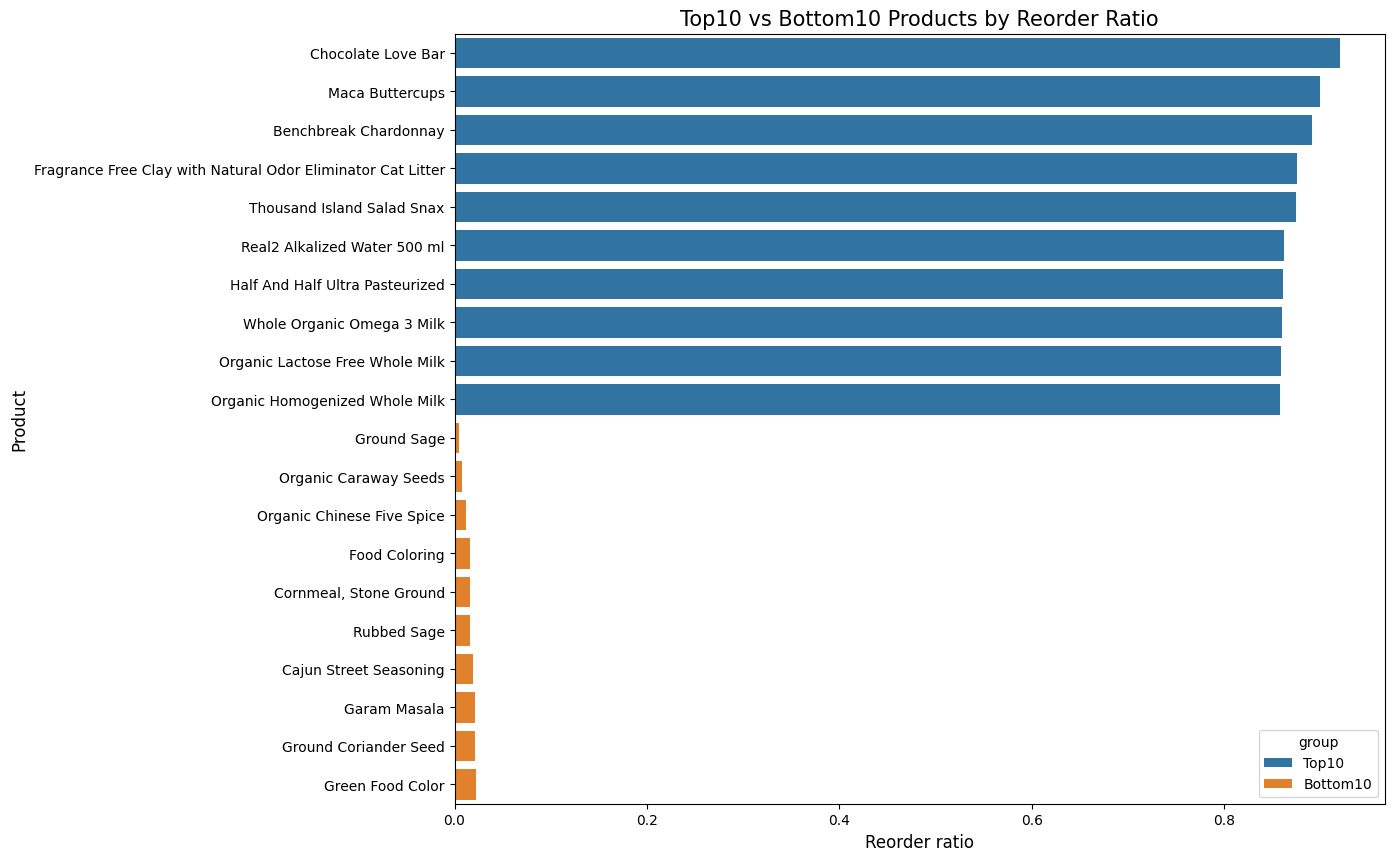

In [40]:
top_bottom = pd.concat([top_reorder.assign(group='Top10'), bottom_reorder.assign(group='Bottom10')])

plt.figure(figsize=(12,10))
sns.barplot(x='reorder_ratio', y='product_name', hue='group', data=top_bottom, dodge=False)
plt.xlabel('Reorder ratio', fontsize=12)
plt.ylabel('Product', fontsize=12)
plt.title('Top10 vs Bottom10 Products by Reorder Ratio', fontsize=15)
plt.show()

### 결론
재구매율이 가장 높은 상품군은 우유·유제품류였고, 가장 낮은 상품군은 향신료류로 나타났다.
이는 인기 상품과 재구매가 잘 되는 상품을 다른 개념임을 보여준다.